# `velocity_ot` — train an OT velocity field and plot trajectories

Runs the full pipeline end-to-end:

1. **Load data** into an `AnnData` (your own, or a synthetic rotating ring).
2. **Fit** an autonomous velocity field `v_φ : ℝ^D → ℝ^D` with `VelocityFieldEstimator`.
3. **Inspect** the fitted field (streamplot) and training curves.
4. **Integrate & plot trajectories** rolled forward from seed points.
5. Read the **outputs** written back into `adata.obsm["velocity_field"]`.

**Data contract:** spatial coordinates in `adata.X` `[N, D]`; circular
coordinate (radians) in `adata.obs['circular_coords']` `[N]`.

**The four loss terms** (all optimal-transport terms via `POT`):
`L = λ₁·KE + λ₂·stationarity + λ₃·align + λ₄·OT_sub`, where *stationarity*
flows a localized arc around the cycle and matches its time-marginal to the full
data, and *OT_sub* enforces that a subset returns to itself after one cycle.

> Place this notebook next to the `velocity_ot/` package folder (or adjust the
> path in the first cell).

In [1]:
# --- imports & setup ---
import sys, pathlib
PKG_PARENT = None  # set to the folder that CONTAINS velocity_ot/ if needed
if PKG_PARENT:
    sys.path.insert(0, PKG_PARENT)
else:
    for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        if (p / "velocity_ot" / "__init__.py").exists():
            sys.path.insert(0, str(p)); break

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
%matplotlib inline

import velocity_ot as vo
print("velocity_ot", vo.__version__)

velocity_ot 0.1.0


## 1. Load your data

The estimator reads:

- **coordinates** `x` from `adata.X` — shape `[N, D]`;
- **circular coordinate** `θ` (radians in `[0, 2π)`) from
  `adata.obs['circular_coords']` — shape `[N]`.

**Don't have `θ`?** Compute a *persistent-cohomology circular coordinate*
(e.g. `dreimac.CircularCoords`) from your point cloud and store it (in radians)
as `adata.obs['circular_coords']`. `θ` is the phase of the cycle each point sits at.

Set `USE_YOUR_OWN_DATA = True` and fill in the block below. Otherwise a
synthetic rotating ring is used so the notebook runs out of the box.

In [2]:
# ======================= PLUG IN YOUR DATA HERE =======================
USE_YOUR_OWN_DATA = False

if USE_YOUR_OWN_DATA:
    # --- Option A: from an .h5ad (spatial in .X, circular coord in obs) ---
    # adata = ad.read_h5ad("path/to/your.h5ad")
    # assert "circular_coords" in adata.obs

    # --- Option B: from numpy arrays you have in memory ---
    # coords = ...                      # [N, D] float  (spatial coordinates)
    # theta  = ...                      # [N] radians in [0, 2*pi)
    # adata = ad.AnnData(X=coords.astype("float32"))
    # adata.obs["circular_coords"] = np.asarray(theta, dtype="float32")
    raise NotImplementedError("Fill in your data, then set USE_YOUR_OWN_DATA = True.")
else:
    # --- Synthetic fallback: a rotating ring with non-uniform angular density ---
    rng = np.random.default_rng(0)
    N = 400
    theta  = np.sort(rng.beta(2.0, 5.0, size=N) * 2.0 * np.pi)   # clumped phases
    radius = 1.0 + 0.03 * rng.standard_normal(N)
    coords = np.stack([radius * np.cos(theta), radius * np.sin(theta)], axis=1).astype("float32")

    adata = ad.AnnData(X=coords)                            # spatial -> adata.X
    adata.obs["circular_coords"] = theta.astype("float32")  # circular coord -> obs

print("adata:", adata)
print("X", adata.X.shape, "| circular_coords", adata.obs["circular_coords"].shape)

adata: AnnData object with n_obs × n_vars = 400 × 2
    obs: 'circular_coords'
X (400, 2) | circular_coords (400,)


### Quick look at the data (coloured by θ)

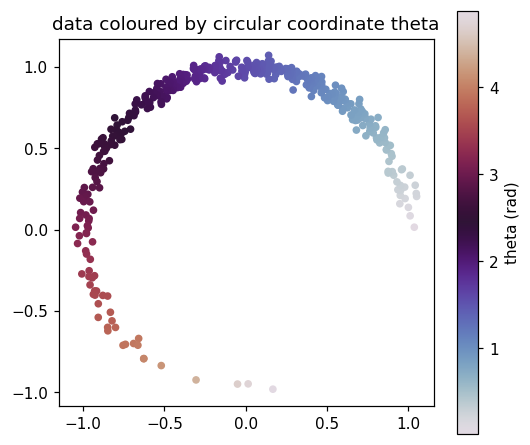

In [3]:
fig, ax = plt.subplots(figsize=(5.5, 5), dpi=110)
c = np.asarray(adata.obs["circular_coords"])
sc = ax.scatter(adata.X[:, 0], adata.X[:, 1], c=c, cmap="twilight", s=16)
ax.set_aspect("equal"); ax.set_title("data coloured by circular coordinate theta")
fig.colorbar(sc, ax=ax, label="theta (rad)"); plt.show()

## 2. Fit the velocity field

Key knobs:

- `intrinsic_dim` — manifold dimension for estimating `∇θ` (`1` for a circle).
- `lambda_*` — weights of the four loss terms.
- `stationarity_seed_frac` — size of the localized arc that seeds the
  stationarity term (small ⇒ the clump must flow further to reproduce the data).
- `n_steps` / `method` — ODE integration for one cycle.

By default coordinates come from `adata.X` and `θ` from
`adata.obs['circular_coords']`, so `fit` needs no key arguments. Training prints
the four loss terms per logged epoch.

In [4]:
est = vo.VelocityFieldEstimator(
    hidden_dims=(64, 64),
    activation="silu",
    n_steps=12,               # ODE steps per cycle during training
    method="rk4",
    T=1.0,                    # one normalised cycle
    lambda_ke=1e-4,           # gentle kinetic-energy regularisation
    lambda_stationarity=2.0,  # time-marginal of localized arc == data
    lambda_align=1.0,         # follow +grad(theta)
    lambda_ot_sub=1.0,        # subset returns to itself after one cycle
    sinkhorn_reg=0.05,
    sinkhorn_iter=100,
    stationarity_n_points=200,
    stationarity_seed_frac=0.1,
    intrinsic_dim=1,          # ring => 1-D manifold
    knn=12,
    lr=5e-3,
    device=None,              # None -> CUDA if available, else CPU
    seed=0,
    verbose=True,
)

est.fit(adata, n_epochs=150)   # reads adata.X and adata.obs['circular_coords']

[epoch    0] total=2.3173  KE=0.4524  stationarity=0.7505  align=0.5005  OT_sub=0.3158


[epoch   15] total=0.6879  KE=7.7520  stationarity=0.1735  align=0.1756  OT_sub=0.1646


[epoch   30] total=0.4486  KE=10.2281  stationarity=0.0984  align=0.1587  OT_sub=0.0921


[epoch   45] total=0.3778  KE=12.9898  stationarity=0.0736  align=0.1567  OT_sub=0.0727


[epoch   60] total=0.3291  KE=15.1850  stationarity=0.0600  align=0.1631  OT_sub=0.0444


...

[epoch   90] total=0.2795  KE=19.8774  stationarity=0.0520  align=0.1437  OT_sub=0.0298


[epoch  105] total=0.2757  KE=18.8463  stationarity=0.0515  align=0.1155  OT_sub=0.0552


[epoch  120] total=0.2588  KE=21.6789  stationarity=0.0467  align=0.1286  OT_sub=0.0346


[epoch  135] total=0.2400  KE=24.3426  stationarity=0.0487  align=0.1125  OT_sub=0.0277


[epoch  149] total=0.2834  KE=20.5831  stationarity=0.0548  align=0.1222  OT_sub=0.0496


### Training curves

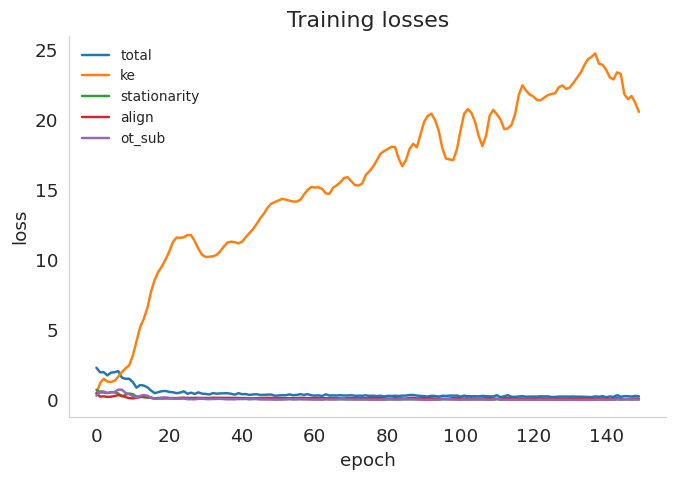

In [5]:
ax = vo.plot_loss_history(est)
plt.show()

## 3. Inspect the fitted velocity field

For 2-D data the streamplot shows the whole field, coloured by speed. It should
circulate around the ring, following the circular-coordinate gradient.

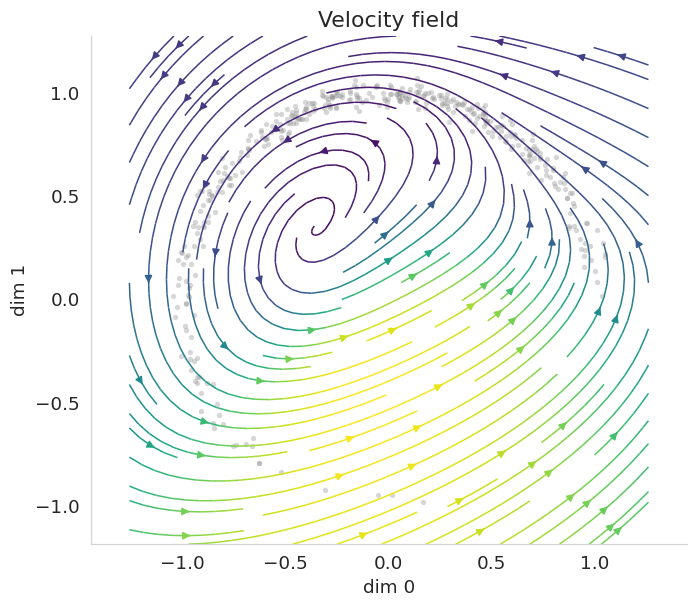

mean speed |v|          : 4.200
mean cos(v, +theta dir) : 0.977   (1.0 = perfectly rotational)


In [6]:
ax = vo.plot_velocity_field(est, adata.X, streamplot=True, quiver=False)
plt.show()

# how rotational is it? (cosine with the analytic +theta tangent, for the ring)
v = adata.obsm["velocity_field"]
th = np.asarray(adata.obs["circular_coords"])
tangent = np.stack([-np.sin(th), np.cos(th)], axis=1)
cos = (v * tangent).sum(1) / (np.linalg.norm(v, axis=1) * np.linalg.norm(tangent, axis=1) + 1e-9)
print(f"mean speed |v|          : {np.linalg.norm(v, axis=1).mean():.3f}")
print(f"mean cos(v, +theta dir) : {cos.mean():.3f}   (1.0 = perfectly rotational)")

## 4. Integrate & plot trajectories

Roll seed points forward through the autonomous field for one cycle. Lines are
coloured by time (start = open circle, end = star). The stationarity term drives
the flow to sweep the whole ring; with enough training the trajectories close
after one cycle.

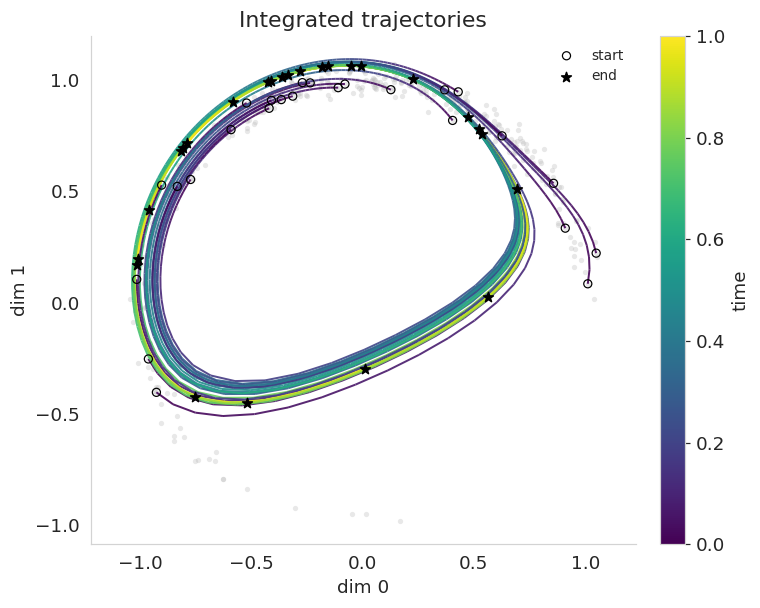

In [7]:
ax = vo.plot_trajectories(est, X=adata.X, n_seeds=25, T=1.0, n_steps=120, method="rk4")
plt.show()

trajectory array: (101, 10, 2)   (n_steps+1, n_seeds, D)
times: (101,) from 0.0 to 1.0


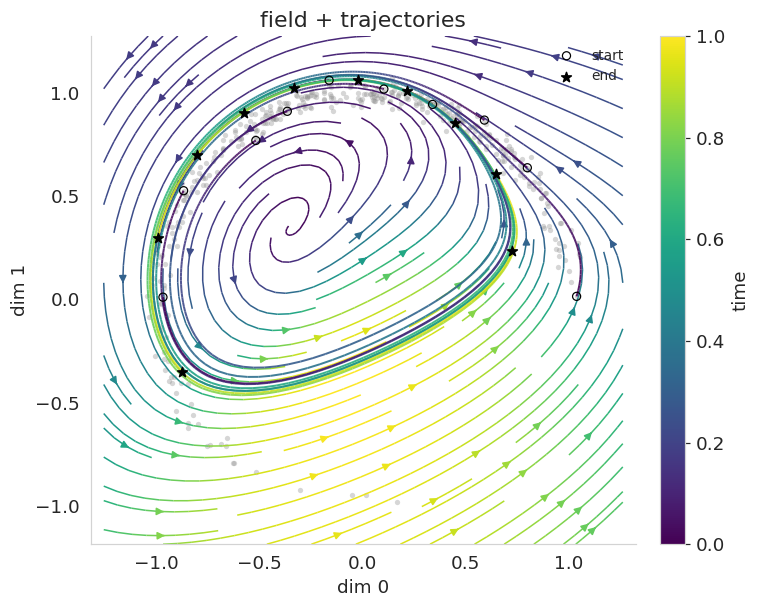

In [8]:
# Raw trajectory array for your own analysis: [n_steps+1, n_seeds, D]
seeds = adata.X[::40]
traj, times = vo.integrate_trajectories(est, seeds, T=1.0, n_steps=100)
print("trajectory array:", traj.shape, "  (n_steps+1, n_seeds, D)")
print("times:", times.shape, "from", round(float(times[0]), 2), "to", round(float(times[-1]), 2))

# Field + a few smoothed trajectories together.
fig, ax = plt.subplots(figsize=(7, 6), dpi=110)
vo.plot_velocity_field(est, adata.X, streamplot=True, quiver=False, ax=ax,
                       title="field + trajectories")
vo.plot_trajectories(est, seeds=seeds, X=adata.X, T=1.0, n_steps=100, smooth=True,
                     show_background=False, ax=ax, title=None)
plt.show()

## 5. Outputs written back to `AnnData`

`fit` stores results on the object:

- `adata.obsm["velocity_field"]` — fitted velocities at every point.
- `adata.obsm["grad_theta"]` — the estimated grad(theta) target field.
- `adata.uns["velocity_ot"]` — loss history and run configuration.

The field also evaluates at **out-of-sample** points via `est.predict`.

In [9]:
print("obsm keys :", list(adata.obsm.keys()))
print("velocity_field:", adata.obsm["velocity_field"].shape)

grid = np.array([[1.0, 0.0], [0.0, 1.0], [-1.0, 0.0], [0.0, -1.0]], dtype="float32")
print("v at (+/-1,0),(0,+/-1):\n", np.round(est.predict(grid), 3))

# adata.write_h5ad("velocity_ot_result.h5ad")   # persist if you like

obsm keys : ['velocity_field', 'grad_theta']
velocity_field: (400, 2)
v at (+/-1,0),(0,+/-1):
 [[ 3.384  8.684]
 [-2.028  0.348]
 [ 0.771 -6.782]
 [17.262  7.165]]
